# Modelado Jerárquico

In [ ]:
# ==========================
# Entorno estable para PyMC + PreliZ en Colab
# ==========================

!pip uninstall -y \
    preliz \
    pytensor \
    pytensor-distributions \
    arviz_stats \
    numba \
    llvmlite

!pip install -U --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.16.1" \
    "pandas==2.3.0" \
    "matplotlib==3.10.0" \
    "llvmlite==0.43.0" \
    "numba==0.60.0" \
    "arviz==0.22.0" \
    "pymc==5.28.5" \
    "pytensor==2.38.3" \
    "arviz_stats==0.6.0" \
    "preliz==0.20.0"

print("\n==============================")
print("IMPORTANTE")
print("Ahora hacé Runtime > Restart session")
print("y recién después ejecutá las celdas del notebook.")
print("==============================")

In [ ]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-doc")

In [3]:
#| code-fold: true

az.style.use('arviz-doc')

# 1) El Modelo Jerárquico:

En la mayoría de los casos de estudio, los datos con los que trabajamos podrían presentar un agrupamiento o jerarquía incluso muchas veces dada por distintos niveles. En este capítulo estudiaremos dos herramientas que nos serán útiles para abordar este tipo de casos, que son el ***modelado jerárquico*** (con agrupamiento total y parcial) y el posible ***efecto de contracción***.


En estos casos, para trabajar con la distribución a posteriori se introducen los llamados ***hiper-priors*** para poder trabajar a partir de ellos con estimaciones por cada grupo. Esto es, inducimos una agrupación parcial en un punto entre el modelo agrupado y el modelo no agrupado.

Consideremos el estudio del desempeño de alumnos de diferentes escuelas a nivel provincial. Podŕiamos tener información dada por escuelas de distintas ciudades. En este caso tenemos un agrupamiento o jerarquía dado "naturalmente"  en diferentes niveles: *están agrupados por escuela, ciudad y provincia.*

¿Cómo sería el caso de un estudio de salud teniendo en cuenta la información en hospitales?

En muchos casos, tener en cuenta esta situación de agrupamiento no es tan fácil de ver, y muchas veces se ignora por completo, pero no es menor que exista esta estructura jerárquica porque analizar los datos por separado o como un todo, no siempre refleja la relación real de los mismos, ni nos permite obtener estimaciones tan precisas.

El costo de no trabajar con Modelos jerárquicos cuando es debido, es perder detalles y características propias de cada grupo, e incluso diferencias entre ellos, es decir, *se eliminaría la particularidad de la naturaleza de los datos formados por grupos diferentes, pero que al mismo tiempo comparten información.*




<font color="orange"> NOTA: los Modelos Jerárquicos también son conocidos en la literatura cn los siguientes nombres: *modelos multinivel, modelos de efectos mixtos, modelos de efectos aleatorios o modelos anidados.*

## **¿Cómo se construye un modelo jerárquico?**

La idea central de la construcción de un modelo jerárquico, es <font color="pink"> **asignar distribuciones a priori a las distribuciones a priori** </font>, lo que se engloba en la utilización de los hiper-priors, con los que estamos asumiendo que los priors de cada grupo no son nesariamente iguales pero sí se relacionan ya que provienen de una población común.

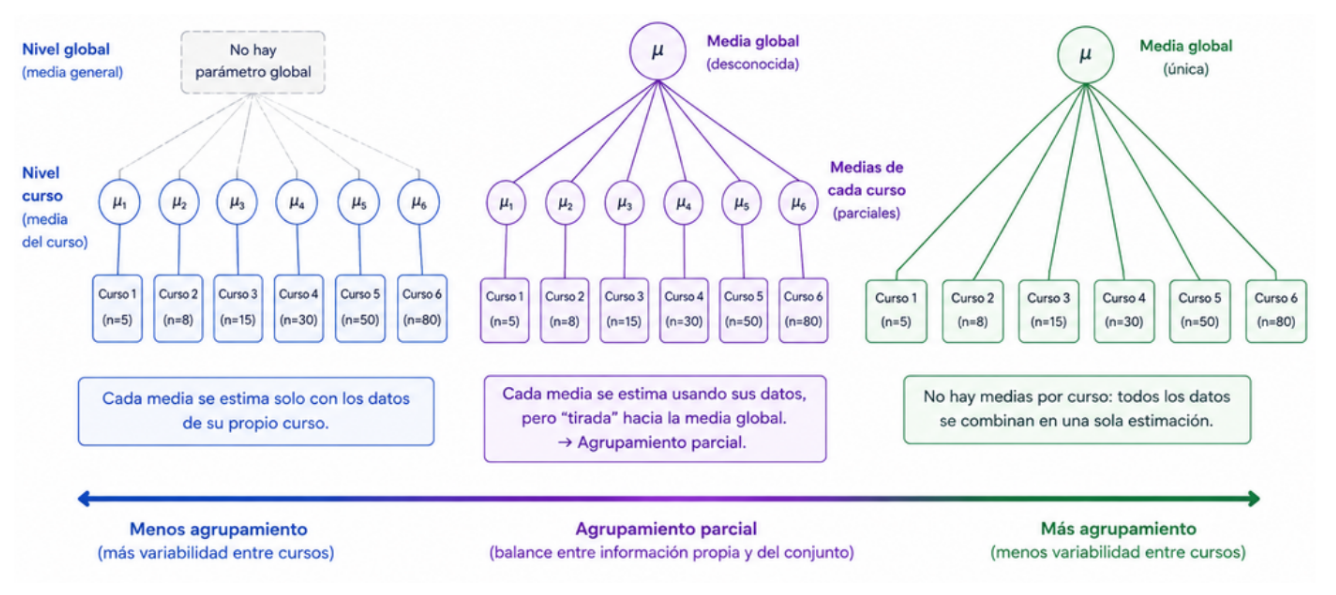

## **El problema de los renacuajos**

Estudiemos la supervivencia de renacuajos en 48 tanques.

En cada tanque se colocó una cantidad conocida de renacuajos y se registró cuántos sobrevivieron.

 Queremos modelar la probabilidad de supervivencia de los renacuajos teniendo en cuenta las condiciones ambientales como la temperatura, el pH, la luz, etc. y  cómo las mismas varían entre cada uno de los tanques.

**¿Por qué necesitamos un modelo jerárquico?:**

porque las condiciones anteriores nos permiten pensar en cada tanque como un grupo, siendo la población común de la que provienen los renacuajos.

**NOTA:** pueden estudiar este ejemplo completo de [statistical rethinking](https://xcelab.net/rm/statistical-rethinking/)





In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


En primer lugar, leeremos los datos y estudiaremos un poco lo que contiene la tabla:

In [11]:
d = pd.read_csv('renacuajos.csv', sep=",")
coords = {"tanks": list(d.index)}


In [ ]:
d.head()

Tenemos las siguientes variables:

* `tank:` identificador del tanque. Indica a qué tanque pertenece cada observación (hay 48 tanques).

* `density:` cantidad de renacuajos colocados inicialmente en el tanque, es decir, la densidad inicial.

* `surv:` cantidad de renacuajos que sobrevivieron al finalizar el experimento.

* `propsurv:` proporción de renacuajos que sobrevivieron en cada tanque. Se calcula como:

$$propsurv=\frac{surv}{density}$$

### **Construímos el modelo:**

Suponemos que, para cada tanque $i=1,…,48,$ el número de renacuajos sobrevivientes sigue una distribución Binomial

$$surv_i ∼ Binomial(n_i ,p_i)$$

donde:

* $surv_i$ representa la cantidad de renacuajos que sobrevivieron en el tanque $i$;

* $n_i$ es la cantidad inicial de renacuajos en dicho tanque (variable density);

* $p_i$ es la probabilidad de supervivencia correspondiente al tanque $i$.

Este modelo es adecuado porque conocemos cuántos renacuajos hay y queremos estimar la probabilidad de supervivencia.

Hasta acá, como se puede ver, es simplemente un modelo Binomial para cada uno de los tanques.

### **¿Cuál es el problema de dejar el modelo tal cual está definido?:**

Pensemos en que, si estimamos una probabilidad $p_i$ diferente para cada tanque, estamos asumiendo que todos los tanques son completamente independientes, pero en realidad la intuición nos hace comenzar a plantearnos que:


1. Algunos tanques tienen muy pocos individuos,
otros muchos.

2. Las estimaciones pueden ser muy inestables.

Entonces necesitamos compartir información.

De este modo nuestro modelos "nos queda un poco débil", y es así como aparece la necesidad del modelo jerárquico para poder incluir las dos situaciones anteriores.

Para cada tanque $i=1,…,48,$, al igual que en el caso previo, el número de renacuajos sobrevivientes sigue una distribución Binomial dada por

$$surv_i ∼ Binomial(n_i , p_i)$$
	​

* $surv_i$ representa la cantidad de renacuajos que sobrevivieron en el tanque $i$;

* $n_i$ es la cantidad inicial de renacuajos en dicho tanque (variable density);

* $p_i$ es la probabilidad de supervivencia correspondiente al tanque $i$.

Como una probabilidad debe tomar valores entre 0 y 1, modelamos $p_i$ mediante una transformación logística aplicada a un parámetro sin restricciones:

$$p_i =logit^{−1}(α_i)= \frac{1}{1+e^{\alpha_i}}$$

Los efectos de cada tanque se consideran provenientes de una distribución común,

$$α_i∼N(μ,σ)$$

donde:

* $μ$ representa el efecto promedio de todos los tanques;

* $σ$ cuantifica la variabilidad entre tanques.

Finalmente, se asignan distribuciones a priori a los hiperparámetros,

$$μ∼N(0,2)$$

$$σ∼HalfNormal(2)$$



<font color="orange"> **Resumen del modelo:** <font>


<font color="orange"> $$surv_i ∼ Binomial(n_i , p_i)$$

<font color="orange"> $$p_i =logit^{−1}(α_i)= \frac{1}{1+e^{\alpha_i}}$$


<font color="orange"> $$α_i∼N(μ,σ)$$


<font color="orange"> $$μ∼N(0,2)$$

<font color="orange"> $$σ∼HalfNormal(2)$$

<font color="orange"> $i=1,…,48.$

**Pensemos cómo se componen los niveles de este modelo:**

Podemos pensarlo en tres niveles principales:

1. *Nivel de los datos:* para cada tanque observamos cuántos renacuajos sobrevivieron de los que fueron colocados inicialmente. Por eso usamos una distribución Binomial:
$$surv_i​∼Binomial(n_i​,p_i​)$$

2. *Nivel de los tanques:* cada tanque tiene su propia probabilidad de supervivencia $p_i$, que se expresa mediante $α_i$. Sin embargo, estos efectos no se estiman de manera completamente independiente, sino que provienen de una distribución común:
$$α_i​∼N(μ,σ)$$
Así, los tanques comparten información.

3. *Nivel de la población de tanques:* los parámetros que describen esa distribución común, $μ$ y $σ$, también tienen sus propias distribuciones a priori:
$$μ∼N(0,2)$$
$$σ∼HalfNormal(2)$$

<font color="pink"> NOTA: tenemos observaciones dentro de tanques, tanques dentro de una población común. Esta estructura permite que los tanques con pocos datos puedan beneficiarse de la información de los demás, evitando estimaciones demasiado extremas o inestables.

## **Intercambiabilidad:**

Hasta este momento hemos considerado que los efectos asociados a los distintos tanques pueden describirse mediante una misma distribución de probabilidad. Esta suposición recibe el nombre de **intercambiabilidad**.

De manera formal, una colección de variables aleatorias ($X_1,X_2,\ldots,X_J)$, ya sea finita o infinita, es **intercambiable** cuando su distribución conjunta no cambia al modificar el orden de las variables. Es decir, podemos permutar sus índices sin alterar el modelo probabilístico.

Llevando esta idea a nuestro ejemplo, estamos suponiendo que, antes de observar los resultados, no contamos con información que nos permita considerar a un tanque como sistemáticamente diferente de los demás.

Por ejemplo, si quitáramos las etiquetas que identifican a cada tanque y solo conserváramos la cantidad de semillas que sobrevivieron en cada uno, no tendríamos motivos para pensar que el tanque 3 tiene una probabilidad de supervivencia diferente de la del tanque 18 simplemente por ocupar una determinada posición o tener un determinado número.

Para verlo con mayor claridad, supongamos que realizamos el experimento utilizando diez tanques y que el resultado correspondiente al tanque 4 permanece oculto. Para los otros nueve tanques conocemos las proporciones de supervivencia:


| Tanque | Proporción |
| ------ | ---------- |
| 1      | 0.62       |
| 2      | 0.55       |
| 3      | 0.58       |
| 5      | 0.61       |
| 6      | 0.59       |
| 7      | 0.53       |
| 8      | 0.57       |
| 9      | 0.60       |
| 10     | 0.56       |


¿Qué podemos decir entonces sobre el tanque 4?

Bajo la hipótesis de **intercambiabilidad**, no podemos conocer exactamente su proporción de supervivencia, pero sí podemos utilizar la información de los otros tanques para obtener una expectativa razonable sobre su resultado.

Ahora bien, si supiéramos que el tanque 4 estuvo sometido a condiciones diferentes, ya no sería razonable tratarlo como intercambiable con los demás. Esa información debería incorporarse al modelo.

Por último, **intercambiabilidad no significa independencia**. Una secuencia iid siempre es intercambiable, pero una secuencia intercambiable no necesariamente es independiente. Esta distinción es fundamental en los **modelos jerárquicos**, porque permite compartir información entre los distintos grupos.


## **Teorema de De Finetti:**

Veamos un teorema muy importante que fundamenta matemáticamente la hipótesis de intercambiabilidad:

Este resultado se conoce como <font color="orange"> ***Teorema de De Finetti*** </font> y establece que una secuencia de variables intercambiables se puede representar como variables condicionalmente independientes dado un parámetro latente.

Esto es:





una secuencia de variables aleatorias es intercambiable si y solo si para todo $n$ podemos escribir:


$$p(X_1, X_2,  \dots , X_n) = \int \prod_i^n p(X_i \mid \theta) \; p(\theta)$$

Es decir, que un conjunto de variable aleatorias puede ser descrito por:

* un parámetro $\theta$
* un likelihood $p(X \mid \theta)$
* un prior $p(\theta)$


Supongamos ahora que $\theta$ representa un conjunto de parámetros, $\theta = (\theta_1, \theta_2,  \dots , \theta_n)$ y que este conjunto de parámetros es intercambiable. Entonces podemos escribir:

$$(\theta_1, \theta_2,  \dots , \theta_n) = \int \prod_i^n p(\theta_i \mid \psi) \; p(\psi)$$


Obteniendo un modelo jerárquico que podríamos reescribir como:


\begin{align*}
X_{ij} &\sim p(X \mid \theta_i) \\
\theta_i &\sim p(\theta \mid \psi)  \\
\psi &\sim p(\psi)
\end{align*}


In [ ]:
with pm.Model(coords=coords) as modelo_renacuajos:
    # Hiperpriors
    μ = pm.Normal('μ', 0., 2.)
    σ = pm.HalfNormal('σ', 2.)
    # Prior
    α_tanque = pm.Normal('α_tanque', μ, σ, dims="tanks")
    p = pm.Deterministic('p', pm.math.sigmoid(α_tanque))  # transformación logística
    #likelihood
    surv = pm.Binomial('surv', n=d.density, p=p, observed=d.surv)

    idata_renacuajos = pm.sample(2000, tune=2000)

In [ ]:
pm.model_to_graphviz(modelo_renacuajos)

En la siguiente figura se comparan las **proporciones observadas** de supervivencia en cada tanque (puntos azules) con las **estimadas por el modelo** (puntos turquesa).

La línea punteada representa la proporción promedio de supervivencia considerando todos los tanques, mientras que las líneas verticales separan los tanques según su densidad inicial: 10, 25 y 35 renacuajos.

Observamos que las estimaciones del modelo se encuentran, en general, más cerca del promedio global que las proporciones observadas. Esto es consecuencia de la **información compartida entre los tanques** y se conoce como **contracción hacia la media**.


definimo suna función logística:

In [15]:
def logistic(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(7, 5))

post_r = az.extract(idata_renacuajos)

ax.scatter(np.arange(0, 48), d.propsurv, color='C0')
ax.scatter(np.arange(0, 48), post_r['p'].mean("sample"), color='C1')
ax.hlines(logistic(post_r['μ'].median("sample")), -1, 49, linestyles='--')

idx = d.density[d.density.diff() > 0].index
ax.vlines(idx + 0.5, -.05, 1.05, lw=.5)
for i, t in zip(np.linspace(0, 48, 7)[1::2], ('pequeño', 'mediano', 'grande')):
    ax.text(i, 0, t, horizontalalignment='center')
ax.set_xlabel('tanques')
ax.set_ylabel('proporción de survivencia')
ax.set_xlim(-1, 48)
ax.set_xticks([])
ax.set_ylim(-.05, 1.05)
ax.grid(False)

### **Caso 1. Modelo no jerárquico (sin pooling)**

Veamos un primer modelo, pero con cada tanque teniendo su propia probabilidad independiente, es decir, cada tanque tiene su propia probabilidad de supervivencia y no comparte información con ningún otro tanque.



In [ ]:
coords = {"tanks": list(d.index)}

with pm.Model(coords=coords) as modelo_no_jerarquico:

    # Un parámetro independiente para cada tanque
    p = pm.Beta("p", alpha=1, beta=1, dims="tanks")

    # Likelihood
    surv = pm.Binomial(
        "surv",
        n=d.density,
        p=p,
        observed=d.surv
    )

    idata_no_jerarquico = pm.sample(
        2000,
        tune=2000,
        random_seed=123
    )

### **Caso 2. Modelo jerárquico (con pooling parcial)**

In [ ]:
with pm.Model(coords=coords) as modelo_jerarquico:

    μ = pm.Normal("μ", 0, 2)
    σ = pm.HalfNormal("σ", 2)

    α_tanque = pm.Normal(
        "α_tanque",
        μ,
        σ,
        dims="tanks"
    )

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(α_tanque)
    )

    surv = pm.Binomial(
        "surv",
        n=d.density,
        p=p,
        observed=d.surv
    )

    idata_jerarquico = pm.sample(
        2000,
        tune=2000,
        random_seed=123
    )

Comparemos ambos modelos:

In [ ]:
post_no = az.extract(idata_no_jerarquico)
post_h = az.extract(idata_jerarquico)

fig, ax = plt.subplots(figsize=(7,5))

ax.scatter(
    np.arange(48),
    d.propsurv,
    color="C0",
    label="Observado"
)

ax.scatter(
    np.arange(48),
    post_no["p"].mean("sample"),
    color="C2",
    label="No jerárquico"
)

ax.scatter(
    np.arange(48),
    post_h["p"].mean("sample"),
    color="C1",
    label="Jerárquico"
)

ax.hlines(
    logistic(post_h["μ"].median("sample")),
    -1,
    49,
    ls="--",
    color="k",
    label="Promedio global"
)

ax.legend()

In [ ]:
az.plot_forest(
    [idata_no_jerarquico,
     idata_jerarquico],
    model_names=[
        "No jerárquico",
        "Jerárquico"
    ],
    var_names="p",
    combined=True,
    figsize=(6,6)
)

Observar que este último gráfico muestra muy bien cómo las estimaciones cambian cuando los grupos comparten información.

El gráfico permite comparar un modelo **sin pooling** con uno de **pooling parcial**.

1. En el modelo no jerárquico, cada tanque se estima de manera independiente, por lo que los tanques con pocos datos presentan mayor variabilidad.

2. El modelo jerárquico permite **compartir información entre los tanques**. Así, las estimaciones con poca evidencia se acercan al promedio global, mientras que las que cuentan con más datos permanecen más próximas a lo observado.

<font color="violet"> ¡¡Este fenómeno se conoce como ***contracción o shrinkage***!!


# **Ejemplo para resolver en clase:**

Una empresa agrícola desea evaluar la calidad de un nuevo tratamiento para semillas. Para ello, se sembraron semillas tratadas en distintos invernaderos. En cada uno se registró si cada semilla logró germinar correctamente.

Cada observación se codifica como:

* 1: la semilla germinó correctamente.
* 0: la semilla no germinó.

Los datos se encuentran agrupados por invernadero. Aunque cada invernadero puede presentar condiciones particulares de temperatura, humedad o iluminación, se supone que todos pertenecen a una misma población y, por lo tanto, resulta razonable modelarlos mediante un enfoque jerárquico.

Para este ejercicio se utilizarán datos sintéticos correspondientes a cuatro invernaderos.

In [21]:

# Cantidad de semillas evaluadas por invernadero
N = [20, 30, 25, 40]

# Cantidad de semillas germinadas
G = [15, 18, 11, 34]

group_idx = np.repeat(np.arange(len(N)), N)

data = []

for i in range(len(N)):
    data.extend(np.repeat([1, 0], [G[i], N[i]-G[i]]))

data = np.array(data)

Actividades:

a) Plantee un modelo jerárquico bayesiano para estimar la probabilidad de germinación de cada invernadero. Describa el significado de cada uno de los parámetros e indique qué distribución asignaría a cada nivel del modelo.

b) Implemente el modelo utilizando PyMC y obtenga muestras de la distribución posterior.

c) Obtenga un resumen posterior de las probabilidades de germinación de cada invernadero y de los hiperparámetros del modelo. ¿Qué información aporta cada uno de ellos?

d) Repita el análisis modificando únicamente los datos del último invernadero para obtener los siguientes escenarios

In [22]:
# Escenario A
G = [15, 18, 11, 34]

In [23]:
# Escenario B
G = [15, 18, 11, 8]

In [24]:
# Escenario C
G = [15, 18, 11, 20]

Compare las estimaciones obtenidas para los tres escenarios y explique cómo influye la información proveniente de los demás invernaderos sobre la estimación del último grupo.

e) A partir de los resultados obtenidos, responda:

¿En qué situaciones el modelo jerárquico produce una mayor contracción (shrinkage)?

¿Qué ventajas presenta este enfoque frente a estimar cada invernadero de manera independiente?

¿En qué circunstancias dejaría de ser razonable asumir que los invernaderos son intercambiables?

Resolución:

Tenemos cuatro invernaderos. En cada uno observamos una cantidad de semillas y cuántas germinaron:

| Invernadero | Semillas (N_i) | Germinadas (G_i) | Proporción observada |
| ----------- | -------------: | ---------------: | -------------------: |
| 1           |             20 |               15 |                 0.75 |
| 2           |             30 |               18 |                 0.60 |
| 3           |             25 |               11 |                 0.44 |
| 4           |             40 |               34 |                 0.85 |


La idea es que cada invernadero puede tener su propia probabilidad de germinación, pero esas probabilidades no son completamente independientes: suponemos que los cuatro invernaderos pertenecen a una misma población.

**a) Planteamiento del modelo jerárquico**

**Nivel 1: datos**

Para cada invernadero $i=1,…,4,$ tenemos $N_i$ semillas y $G_i$ germinaciones.

Por lo tanto:

$$G_i​∼Binomial(N_i​,p_i​)$$

donde:

* $G_i:$ cantidad de semillas que germinaron;
* $N_i:$ cantidad total de semillas evaluadas;
* $p_i:$ probabilidad de germinación del invernadero $i$.

Por ejemplo, para el invernadero 1: $G_1​∼Binomial(20,p_1​)$

**Nivel 2: probabilidades de los invernaderos**

El problema es que $p_i$ debe estar entre 0 y 1. Por eso trabajamos con la escala logística:

$$logit(p_i​)=α_i​$$

o equivalentemente:

$$p_i​=logit^{−1}(α_i​)=\frac{1}{1+e^{−α_i}}​.$$

Ahora podemos modelar los efectos de cada invernadero:

$$α_i∼N(μ,σ)$$

Esta es la parte jerárquica.

La interpretación es:

* $α_i:$ efecto particular del invernadero $i$;

* $μ:$ efecto promedio de la población de invernaderos;

* $σ:$ cuánto varían los invernaderos alrededor de ese promedio.

En otras palabras, no suponemos que los cuatro invernaderos tienen exactamente la misma probabilidad de germinación, pero sí suponemos que sus efectos provienen de una distribución común.

**Nivel 3: hiperparámetros**

Necesitamos asignar priors a $μ$ y $σ$.

Una elección razonable es:

$$μ∼N(0,2)$$

y

$$σ∼HalfNormal(2)$$.

Entonces tenemos el siguiente resumen:

$$G_i∼ Binomial(N_i,p_i)$$
$$p_i∼logit^{-1}(α_i)$$
$$α_i∼N(\mu,σ)$$
$$σ∼HalfNormal(2)$$

con $i=1,…,4$.

***¿Por qué este modelo es jerárquico?:***

Porque tenemos distintos niveles:

Nivel de observación

$$G_i∣p_i$$

Luego
	​
$$α_i​∣μ,σ$$

y por último un "nivel poblacional"

$$μ,σ$$

Observación: Los invernaderos comparten información a través de $μ$ y $σ$, evitando que cada invernadero sea tratado como un problema completamente independiente.

b) **Construyamos le modelo:**

In [25]:
N = np.array([20, 30, 25, 40])
G = np.array([15, 18, 11, 34])

In [26]:
with pm.Model() as modelo:

    # Hiperparámetros
    mu = pm.Normal("mu", mu=0, sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=2)

    # Efectos de cada invernadero
    alpha = pm.Normal(
        "alpha",
        mu=mu,
        sigma=sigma,
        shape=4
    )

    # Probabilidad de germinación
    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(alpha)
    )

    # Datos observados
    germinadas = pm.Binomial(
        "germinadas",
        n=N,
        p=p,
        observed=G
    )

Generamos las muestras:

In [ ]:
with modelo:
    idata = pm.sample(
        2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=123
    )

¿Por qué `target_accept=0.95`?

Porque en modelos jerárquicos puede ser más frecuente encontrar problemas de geometría posterior y divergencias.

Aumentar `target_accept` hace que NUTS utilice pasos más pequeños y puede ayudar a reducirlas.

Pero atención: no significa que poner `target_accept=0.95` haga que cualquier divergencia desaparezca mágicamente. Las divergencias son un diagnóstico que debemos revisar.

Hacemos un resumen de datos de la smuestras generadas:

In [ ]:
az.summary(
    idata,
    var_names=["mu", "sigma", "p", "alpha"],
    round_to=3
)

In [ ]:
az.plot_trace(
    idata,
    var_names=["mu", "sigma", "p"]
)
plt.tight_layout()

In [ ]:
az.plot_energy(idata)
plt.show()

Y trabajamos con un breve análisis de divergencias:

In [ ]:
divergencias = idata.sample_stats["diverging"].sum().item()

print("Número de divergencias:", divergencias)

**¿Qué hacemos si aparecen divergencias?** Si bien en este ejemplo no vamos a tratar con demasiada profundidad, podemos hacer un esquema de cómo intentar reducir las divergencias del modelo.

Si obtenemos, por ejemplo:

*`There were X divergences after tuning.`*

no deberíamos simplemente ignorarlas.

Las divergencias indican que NUTS tuvo dificultades para explorar correctamente alguna región de la distribución posterior.

Podemos intentar cambiar `target_accept`:

In [32]:
#target_accept=0.95

In [33]:
#target_accept=0.99

por ejemplo:

In [ ]:
with modelo:
    idata = pm.sample(
        2000,
        tune=3000,
        chains=4,
        target_accept=0.99,
        random_seed=123
    )

imprimimos las divergencias:

In [ ]:
idata.sample_stats["diverging"].sum().item()

Observen queiInicialmente se observaron algunas divergencias durante el muestreo. Se aumentó target_accept para utilizar pasos de muestreo más conservadores. Luego de volver a ajustar el modelo, las divergencias disminuyeron, por lo que se continuará con la segunda muestra. Como no desaparecieron por completo, las estimaciones deben interpretarse con cautela dado que los posibles problemas de exploración de la distribución posterior y no deberían ignorarse como si fueran simplemente ruido computacional.


c) Resumen posterior

In [ ]:
az.summary(
    idata,
    var_names=["p", "mu", "sigma"],
    hdi_prob=0.94,
    round_to=3
)

**Probabilidades $p_i$:**
	​
  
Tenemos:

$$p_1 ,p_2,p_3,p_4$$

que representan las probabilidades de germinación estimadas para cada invernadero.

No debemos confundirlas con las proporciones observadas.

Las proporciones observadas son:

$$(0.75,0.60,0.44,0.85)$$

Las probabilidades posteriores $p_i$ incorporan tanto los datos del propio invernadero como la información proveniente de los otros invernaderos.


$\mu:$

representa el centro de la distribución de los efectos $α_i.$

Como $μ$ está en escala logística, para interpretarlo en términos de probabilidad podemos transformar, después de extraer muestras:

In [ ]:
mu_post = idata.posterior["mu"]

mu_prob = 1 / (1 + np.exp(-mu_post))

Así obtenemos una medida del nivel poblacional de germinación.

$σ:$

mide la variabilidad entre los invernaderos.

Una interpretación sencilla:

* $σ$ pequeña → los invernaderos tienden a ser parecidos;
* $σ$ grande → hay mayor heterogeneidad entre invernaderos.

Por eso $σ$ es fundamental para entender cuánto pooling o contracción esperamos.

Podemos comparar las proporciones observadas con las estimaciones posteriores:

In [ ]:
post = az.extract(idata)

p_mean = post["p"].mean("sample")

plt.figure(figsize=(8,5))

plt.scatter(
    np.arange(4),
    G / N,
    label="Proporción observada"
)

plt.scatter(
    np.arange(4),
    p_mean,
    label="Media posterior"
)

plt.xticks(
    np.arange(4),
    ["Invernadero 1", "Invernadero 2",
     "Invernadero 3", "Invernadero 4"]
)

plt.ylabel("Probabilidad de germinación")
plt.legend()
plt.show()

Aquí podemos empezar a visualizar el shrinkage.

d) **Comparación de los tres escenarios**

Ahora viene la parte más interesante.

Los primeros tres invernaderos permanecen iguales:

$$G=(15,18,11,⋅)$$

y modificamos únicamente el cuarto.

Tenemos:

Escenario A

$$G_4​=34$$
$$\frac{34}{40}=0.85$$

Escenario B

$$G_4​=34$$
$$\frac{8}{40}=0.2$$

Escenario C

$$G_4​=34$$
$$\frac{20}{40}=0.50$$

Podemos crear una función para no repetir todo el código:

In [35]:
def ajustar_modelo(G, seed=123):

    G = np.array(G)

    with pm.Model() as modelo:

        mu = pm.Normal("mu", mu=0, sigma=2)
        sigma = pm.HalfNormal("sigma", sigma=2)

        alpha = pm.Normal(
            "alpha",
            mu=mu,
            sigma=sigma,
            shape=4
        )

        p = pm.Deterministic(
            "p",
            pm.math.sigmoid(alpha)
        )

        germinadas = pm.Binomial(
            "germinadas",
            n=N,
            p=p,
            observed=G
        )

        idata = pm.sample(
            2000,
            tune=2000,
            chains=4,
            target_accept=0.95,
            random_seed=seed
        )

    return idata

In [ ]:
idata_A = ajustar_modelo([15, 18, 11, 34], seed=123)
idata_B = ajustar_modelo([15, 18, 11, 8], seed=456)
idata_C = ajustar_modelo([15, 18, 11, 20], seed=789)

Comparar el cuarto invernadero

Podemos obtener las medias posteriores:

In [ ]:
def media_p(idata):
    return (
        idata.posterior["p"]
        .mean(dim=("chain", "draw"))
        .values
    )

p_A = media_p(idata_A)
p_B = media_p(idata_B)
p_C = media_p(idata_C)

print("Escenario A:", p_A)
print("Escenario B:", p_B)
print("Escenario C:", p_C)

In [ ]:
print("Invernadero 4:")
print("A:", p_A[3])
print("B:", p_B[3])
print("C:", p_C[3])

¿Qué deberíamos observar?

No debemos esperar que la estimación posterior sea exactamente igual a la proporción observada.

En el escenario A:

$$\hat{p}^{obs}_{4}=0.85$$

Pero el modelo probablemente produzca una estimación menor que 0.85, porque los otros tres invernaderos presentan:

$$0.75,0.60,0.44.$$

Es decir, el cuarto invernadero es relativamente alto respecto del resto.

El modelo lo "acerca" parcialmente hacia la población.

En el escenario B:

$$\hat{p}^{obs}_{4}=0.2$$

Es una proporción bastante menor que la de los otros tres invernaderos.

El modelo jerárquico probablemente produzca una estimación mayor que 0.20.

Nuevamente aparece la contracción hacia el comportamiento general.

En el escenario C:

$$\hat{p}^{obs}_{4}=0.5$$

Esta proporción ya está mucho más cerca del comportamiento de los otros invernaderos.

Por lo tanto, esperamos una menor corrección o contracción.

**¿Por qué sucede esto?**

Porque el modelo no piensa que el invernadero 4 es completamente independiente y tiene que estimar su probabilidad solamente con sus 40 semillas, sino que piensa que el invernadero 4 tiene sus propios datos, pero pertenece a una población de invernaderos que presenta cierto comportamiento general...

Entonces la estimación combina dos fuentes de información:

información propia + información de los demás invernaderos
	​

Eso es precisamente el **pooling parcial**.

**¿Cuál escenario tiene mayor contracción?**


La contracción depende de varios factores:

1. Qué tan extremo es el grupo respecto del promedio poblacional.
2. Cuánta información tiene el grupo.
3. Cuánta variabilidad entre grupos permite el modelo, es decir, el valor de $σ$.

En este ejercicio, fíjense que el cuarto invernadero tiene $N_4=40$, que no es particularmente pequeño.

Por eso su información propia tiene bastante peso.

Aun así, entre los escenarios, A y B presentan observaciones más alejadas del centro de los otros invernaderos, por lo que veremos una modificación respecto de la proporción observada.

El escenario C está mucho más cerca del comportamiento general, por lo que la diferencia entre observación y posterior será menor.

**Algunas observacioens sobre la contracción:**

1. No es correcto decir simplemente que el grupo con la proporción más extrema siempre tiene mayor shrinkage.

2. El shrinkage no depende solamente de qué tan extrema sea la proporción.

3. También depende del tamaño muestral.

$$grupo \ A: \frac{2}{2}=1.00$$
$$grupo \ B: \frac{40}{40}=1.00$$

Ambos tienen la misma proporción observada, pero el segundo tiene mucha más evidencia. Por lo tanto, esperamos que el grupo con $2/2$ experimente mucho más shrinkage.

* menos información propia implica más influencia del promedio poblacional.
* más información propia implica menos contracción.

## **Intercambiabilidad**

Cuando decimos que los invernaderos son intercambiables, no estamos diciendo que sean idénticos.

Estamos diciendo que, antes de observar los datos, no tenemos razones para pensar que un invernadero específico merece un tratamiento diferente de otro.

Por ejemplo, si tenemos: $α_1​,α_2​,α_3​,α_4​$, el modelo supone:

$$α_i∼N(μ,σ)$$

No hay un invernadero que tenga un tratamiento especial.

Si permutáramos las etiquetas de los invernaderos, por ejemplo:

$(1,2,3,4)→(3,1,4,2)$,

el modelo jerárquico sigue siendo esencialmente el mismo.

Observación: lo que importa es qué datos corresponden a cada invernadero, no que el número 1 tenga alguna característica especial por llamarse "invernadero 1".


*¿Cuándo dejaría de ser razonable asumir intercambiabilidad?*

Supongamos que sabemos que los invernaderos pertenecen a regiones climáticas completamente diferentes:

* algunos están en zonas frías;
* otros en zonas tropicales.

* que sabemos que:

1. algunos utilizan una tecnología de iluminación diferente;
2. algunos recibieron un tratamiento distinto;
3. algunos tienen un sistema de riego diferente;
4. algunos pertenecen a establecimientos diferentes;
5. hay una variable ambiental que sabemos que explica parte de las diferencias.

En esos casos, ya tenemos información que distingue a los grupos. Entonces no sería apropiado asumir que todos son intercambiables sin más.

Podríamos incorporar esas variables mediante un modelo jerárquico más elaborado.

Por ejemplo:

$$ logit(p_i​)=α+β_1​temperatura_i​+β_2​humedad_i$$

Y todavía podríamos mantener una estructura jerárquica si existen otros niveles.

<font color="violet"> **Como conclusión: podemos considerar intercambiables a los cuatro invernaderos porque, antes de observar los resultados, suponemos que pertenecen a una misma población y no contamos con información que permita distinguir a uno de ellos de los demás. Por eso modelamos sus efectos mediante una distribución común. La intercambiabilidad no implica que tengan la misma probabilidad de germinación, sino que las diferencias entre ellos se consideran variaciones dentro de una misma población.**

**¿Qué ventajas tiene frente a estimar cada invernadero por separado?**

Si hiciéramos cuatro modelos independientes:

$$G_i​∼Binomial(N_i​,p_i​)$$

y asignáramos a cada $p_i$ un prior independiente, cada invernadero aprendería exclusivamente de sus propios datos.

Eso puede generar estimaciones muy extremas cuando tenemos pocos datos.

El modelo jerárquico permite:

1. Compartir información: porque los invernaderos informan indirectamente sobre los demás mediante $μ$ y $σ$.

2. Reducir estimaciones extremas: un resultado como $0/2$ o $2/2$ no necesariamente produce una estimación posterior cercana a 0 o 1.

3. Mejorar la estimación de grupos pequeños: los grupos con poca información reciben más influencia de la población.

4. Mantener diferencias entre grupos: esto es importante porque no estamos haciendo pooling completo. No estamos diciendo:

$$p_1=p_2=p_3=p_4$$

Cada invernadero conserva su propio $p_i$, y es por esto que hablamos de pooling parcial.